In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from astral.sun import sun
from astral import LocationInfo
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# 1. Load Cleaned Data

In [2]:
df_cleaned = pd.read_csv('../data/cleaned_data.csv')
df_cleaned['Timestamp'] = pd.to_datetime(df_cleaned['Timestamp'], errors='coerce')
df_cleaned.shape

(14520, 13)

In [3]:
df_cleaned.head()

,Timestamp,Wind_Dir_deg,Wind_Speed_ms,Humidity_pct,Outdoor_Temp_C,PV_Temperature,Solar_Radiation_Wm2,DC,PM10_ugm3,PM25_ugm3,uv_index Index,Rain_mm,dew_point_2m (°C)
0,2024-05-18 11:00:00,152.0,1.9,47.8,29.6,33.3,12.0,1540.0,101.7,40.9,5.65,0.0,16.7
1,2024-05-18 12:00:00,56.0,3.9,57.7,28.4,30.5,440.0,1990.0,106.8,44.8,6.40,0.0,16.7
2,2024-05-18 13:00:00,79.0,3.4,48.2,28.6,33.1,886.0,3530.0,108.1,38.9,5.45,0.0,17.1
3,2024-05-18 14:00:00,87.0,3.0,51.3,28.1,29.4,369.0,2180.0,109.5,36.4,4.70,0.0,16.3
4,2024-05-18 15:00:00,26.0,4.9,55.5,28.3,29.8,787.0,3160.0,100.8,37.5,3.15,0.0,16.4


# 2. Preprocessing

Applies the treatment decisions motivated by the Diagnostic EDA notebook: restrict to daylight hours, then impute remaining gaps.

## Filter to Overall Date Range

In [4]:
start_date = '2024-05-19 00:00:00'
end_date = '2026-01-13 07:00:00'

mask = (df_cleaned['Timestamp'] >= start_date) & (df_cleaned['Timestamp'] <= end_date)
df_cleaned = df_cleaned.loc[mask].copy()
print(f"Filtered data to be between {start_date} and {end_date}. New shape: {df_cleaned.shape}")

Filtered data to be between 2024-05-19 00:00:00 and 2026-01-13 07:00:00. New shape: (14504, 13)


## Filter to Daytime Hours (Sunrise–Sunset)

Using the diagnostic boxplot's finding that AC output is negligible/noisy outside daylight, we compute actual sunrise/sunset times for the plant's location and keep only daytime rows.

In [5]:
df_filtered = df_cleaned.copy()

location = LocationInfo("Sfax", "Tunisia", "Africa/Tunis", 34.7167, 10.6833)
print("Location defined for Sfax, Tunisia.")

if 'Timestamp' in df_filtered.columns:
    df_filtered.set_index('Timestamp', inplace=True)

df_filtered.index = df_filtered.index.tz_localize('Africa/Tunis')
print("Localized the time index to 'Africa/Tunis' to match sunrise/sunset calculations.")

def is_daytime(row):
    s = sun(location.observer, date=row.date(), tzinfo=location.timezone)
    return s['sunrise'] <= row <= s['sunset']

daytime_mask = df_filtered.index.to_series().apply(is_daytime)
df_filtered = df_filtered[daytime_mask].copy()
print(f"Filtered for daytime hours only. Shape changed from {df_cleaned.shape} to {df_filtered.shape}.")

df_filtered.index = df_filtered.index.tz_convert(None)
df_filtered.reset_index(inplace=True)

Location defined for Sfax, Tunisia.
Localized the time index to 'Africa/Tunis' to match sunrise/sunset calculations.
Filtered for daytime hours only. Shape changed from (14504, 13) to (7360, 12).


### Verify: AC Power by Hour of Day After Filtering

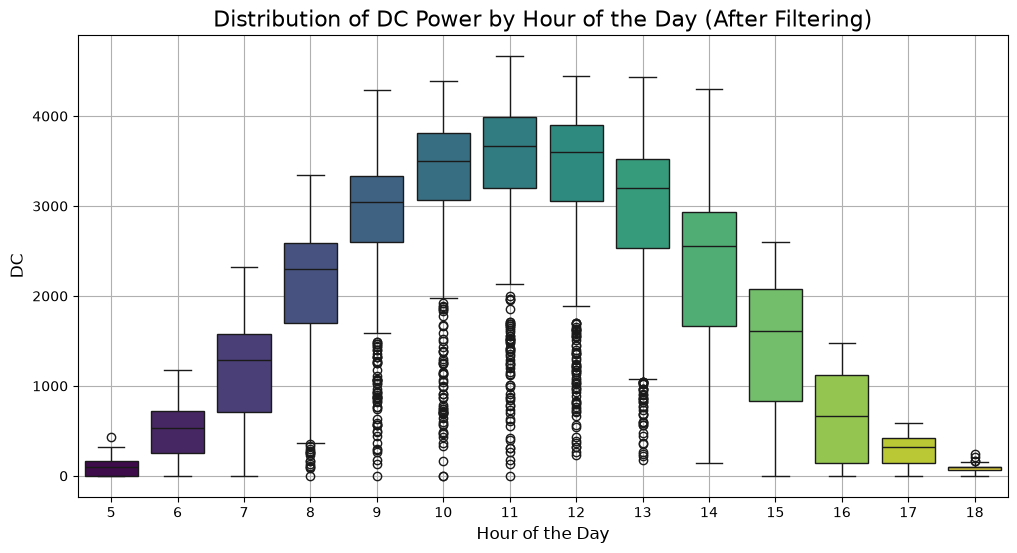

In [6]:
os.makedirs('../figures', exist_ok=True)

df_filtered['Hour_of_Day'] = df_filtered['Timestamp'].dt.hour

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Hour_of_Day',
    y='DC',
    hue='Hour_of_Day',
    data=df_filtered,
    palette='viridis',
    legend=False
)
plt.title('Distribution of DC Power by Hour of the Day (After Filtering)', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('DC', fontsize=12)
plt.grid(True)
plt.savefig('../figures/Distribution_of_DC_Power_by_Hour_of_the_Day_After_Filtering.png',
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

df_filtered.drop(columns=['Hour_of_Day'], inplace=True)

## Save filtered data

In [7]:
df_filtered.to_csv("../data/filtered_data.csv", index=False)

In [8]:
df_filtered.shape

(7360, 13)

## Missing Values in Filtered Data

In [9]:
df_filtered.set_index('Timestamp', inplace=True)
missing_values = df_filtered.isnull().sum()
print(missing_values)

Wind_Dir_deg            600
Wind_Speed_ms           600
Humidity_pct            600
Outdoor_Temp_C          600
PV_Temperature          600
Solar_Radiation_Wm2     600
DC                     1045
PM10_ugm3                 0
PM25_ugm3                 0
uv_index Index            0
Rain_mm                   0
dew_point_2m (°C)         0
dtype: int64


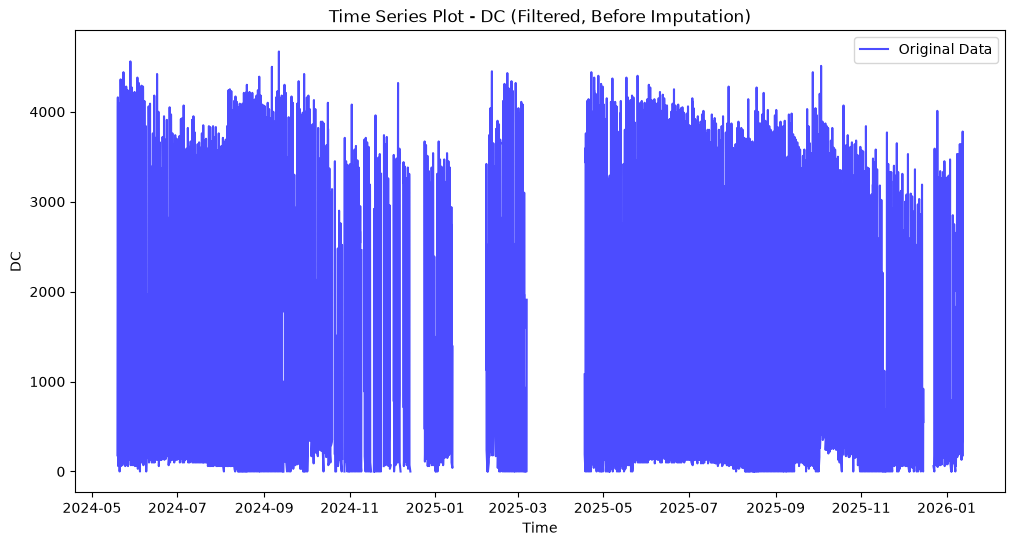

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df_filtered.index, df_filtered['DC'], label="Original Data", color="blue", alpha=0.7)
plt.xlabel("Time")
plt.ylabel('DC')
plt.title("Time Series Plot - DC (Filtered, Before Imputation)")
plt.legend()
plt.show()

# 3. Imputation of Missing Values Using KNN

In [11]:
print("--- Starting Imputation Process ---")
print("Initial missing values")
print(df_filtered.isnull().sum())

# Scale first so KNN's distance metric isn't dominated by large-magnitude columns
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df_filtered)

imputer = KNNImputer(n_neighbors=5)
imputed_scaled = imputer.fit_transform(scaled_values)

imputed_data = scaler.inverse_transform(imputed_scaled)
df_imputed = pd.DataFrame(imputed_data, columns=df_filtered.columns, index=df_filtered.index)

print("Imputation complete.")
print(df_imputed.isnull().sum())

--- Starting Imputation Process ---
Initial missing values
Wind_Dir_deg            600
Wind_Speed_ms           600
Humidity_pct            600
Outdoor_Temp_C          600
PV_Temperature          600
Solar_Radiation_Wm2     600
DC                     1045
PM10_ugm3                 0
PM25_ugm3                 0
uv_index Index            0
Rain_mm                   0
dew_point_2m (°C)         0
dtype: int64
Imputation complete.
Wind_Dir_deg           0
Wind_Speed_ms          0
Humidity_pct           0
Outdoor_Temp_C         0
PV_Temperature         0
Solar_Radiation_Wm2    0
DC                     0
PM10_ugm3              0
PM25_ugm3              0
uv_index Index         0
Rain_mm                0
dew_point_2m (°C)      0
dtype: int64


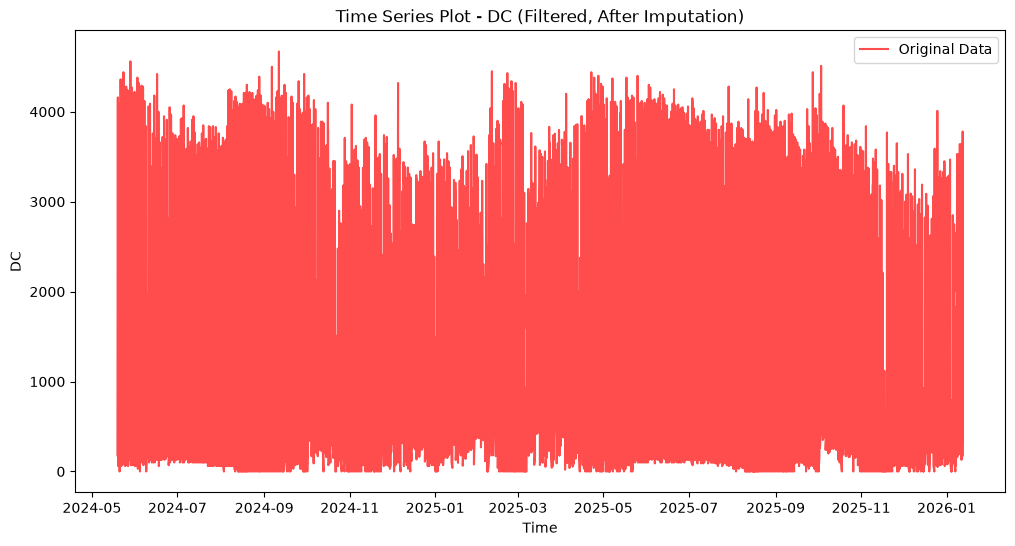

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df_imputed.index, df_imputed['DC'], label="Original Data", color="red", alpha=0.7)
plt.xlabel("Time")
plt.ylabel('DC')
plt.title("Time Series Plot - DC (Filtered, After Imputation)")
plt.legend()
plt.show()

## Compare Original vs Imputed

Creating grid comparison plot for columns with imputed values: ['Wind_Dir_deg', 'Wind_Speed_ms', 'Humidity_pct', 'Outdoor_Temp_C', 'PV_Temperature', 'Solar_Radiation_Wm2', 'DC']


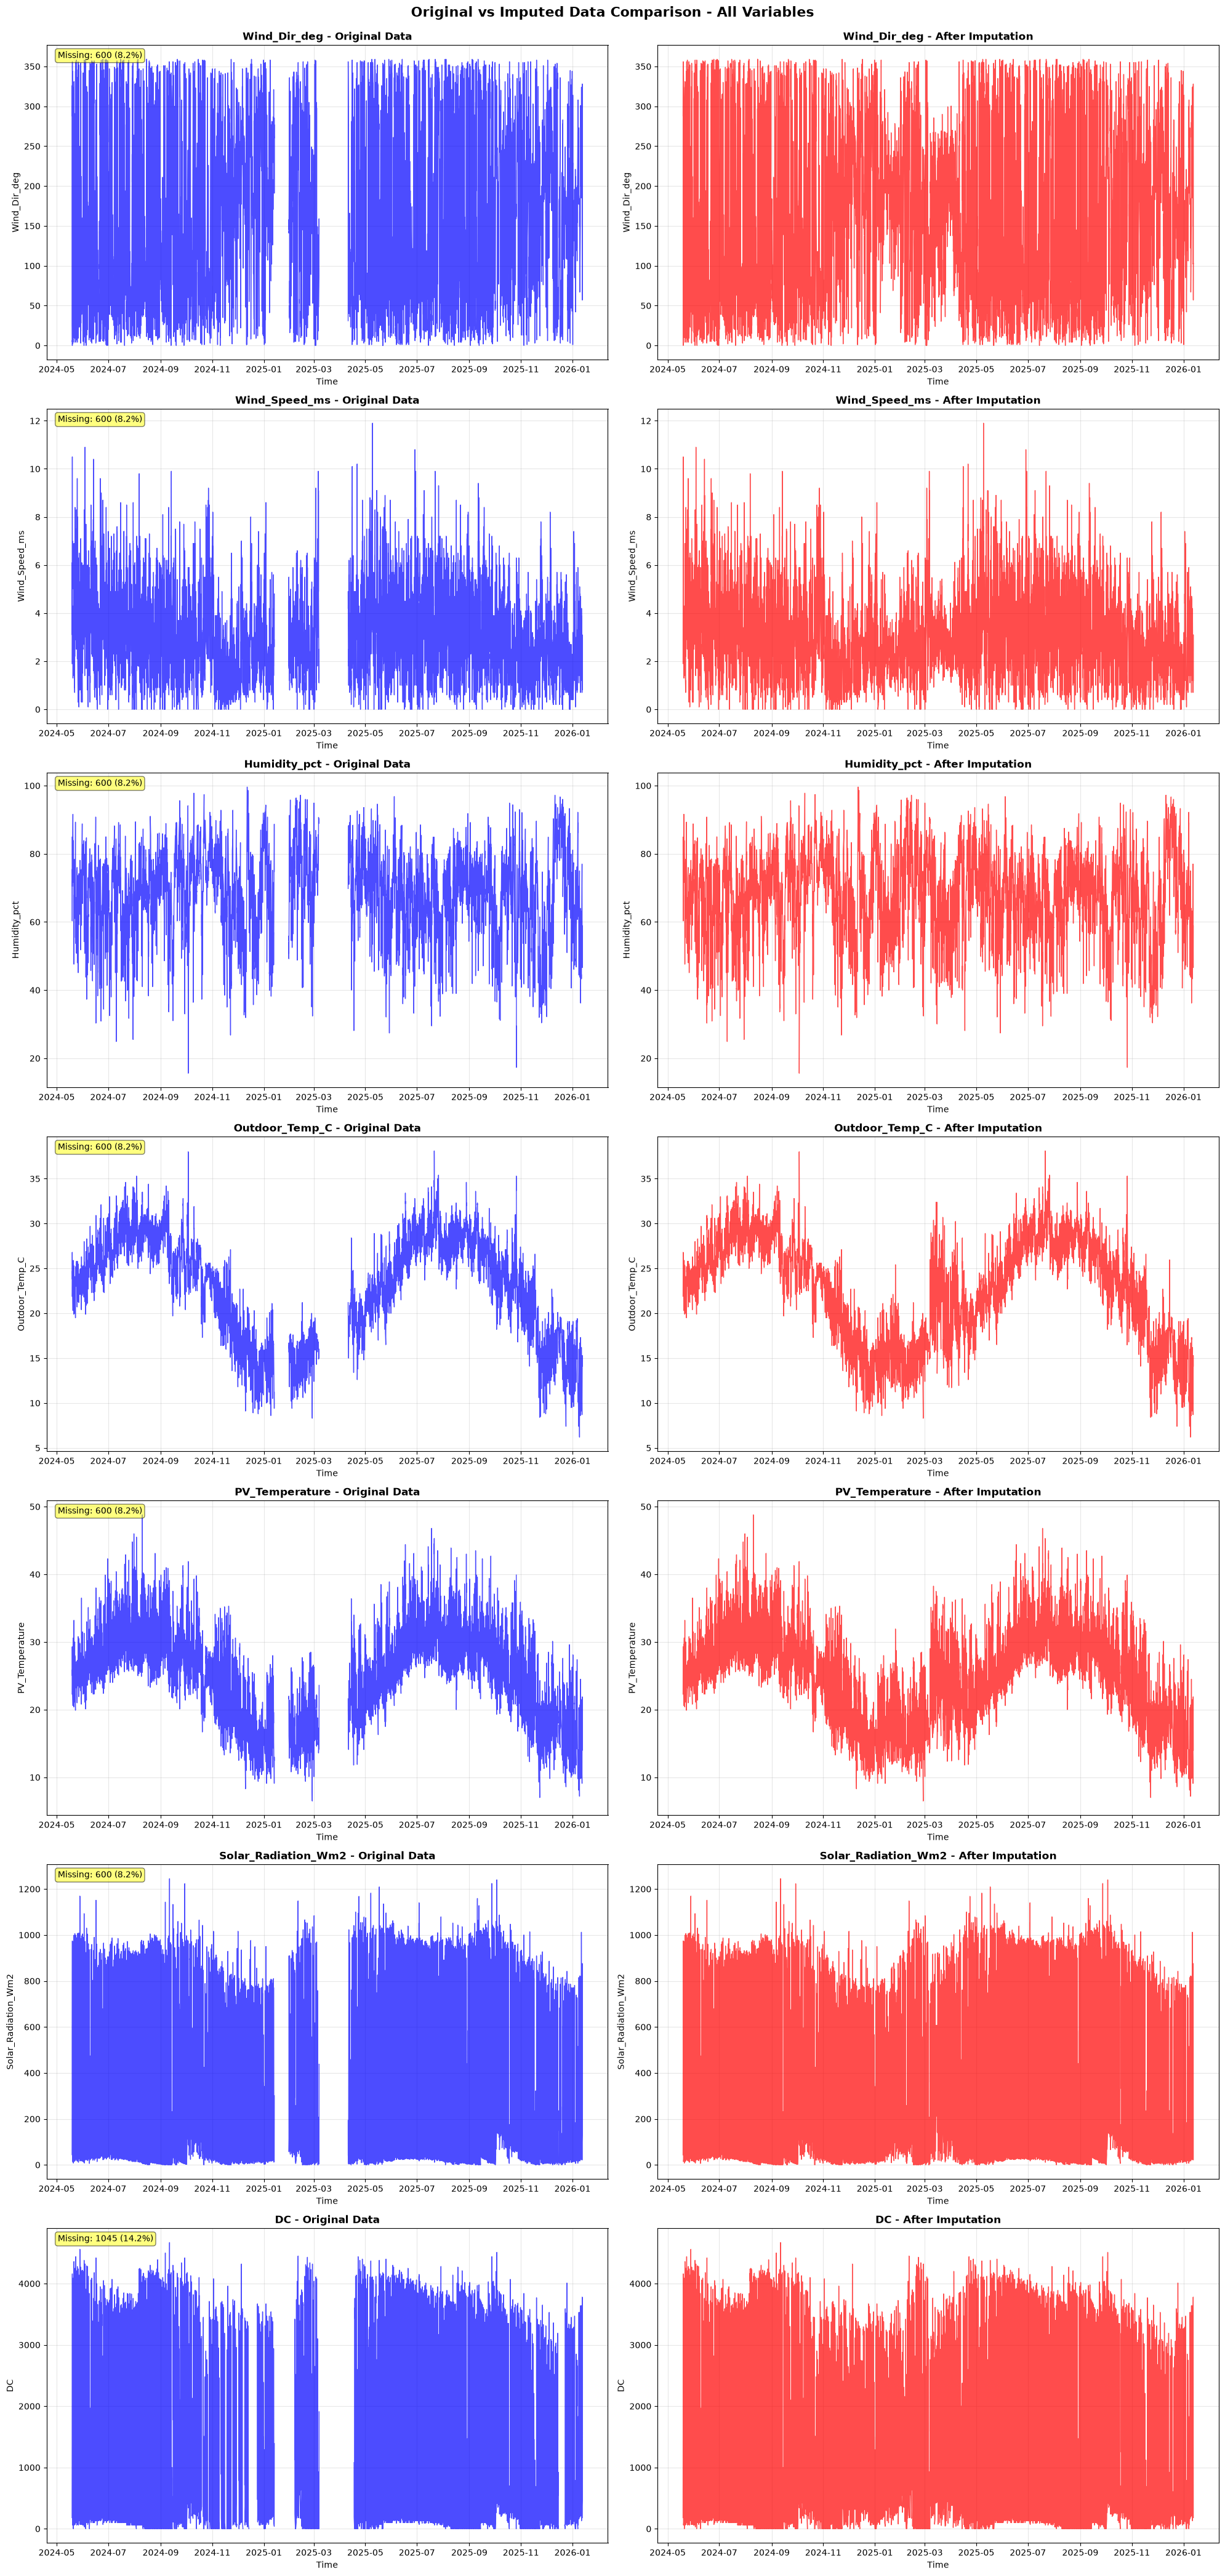

Saved combined grid plot: All_Variables_Original_vs_Imputed_Grid.png


In [13]:
numeric_columns = df_filtered.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns = [col for col in numeric_columns if col not in ['Hour_of_Day']]

columns_to_plot = [col for col in numeric_columns if df_filtered[col].isnull().sum() > 0]

print(f"Creating grid comparison plot for columns with imputed values: {columns_to_plot}")

n_rows = len(columns_to_plot)
n_subplot_cols = 2

fig, axes = plt.subplots(n_rows, n_subplot_cols, figsize=(20, 6*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(columns_to_plot):
    ax1 = axes[i, 0]
    ax1.plot(df_filtered.index, df_filtered[col], color="blue", alpha=0.7, linewidth=1)
    ax1.set_xlabel("Time")
    ax1.set_ylabel(col)
    ax1.set_title(f"{col} - Original Data", fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    missing_mask = df_filtered[col].isnull()
    if missing_mask.any():
        missing_count = missing_mask.sum()
        missing_percent = (missing_count / len(df_filtered)) * 100
        ax1.text(0.02, 0.98, f'Missing: {missing_count} ({missing_percent:.1f}%)',
                transform=ax1.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

    ax2 = axes[i, 1]
    ax2.plot(df_imputed.index, df_imputed[col], color="red", alpha=0.7, linewidth=1)
    ax2.set_xlabel("Time")
    ax2.set_ylabel(col)
    ax2.set_title(f"{col} - After Imputation", fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
    y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
    ax1.set_ylim(y_min, y_max)
    ax2.set_ylim(y_min, y_max)

fig.suptitle('Original vs Imputed Data Comparison - All Variables', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.subplots_adjust(top=0.98)

filename = "All_Variables_Original_vs_Imputed_Grid.png"
plt.savefig(f'../figures/{filename}', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print(f"Saved combined grid plot: {filename}")

In [14]:
df_filtered.describe()

,Wind_Dir_deg,Wind_Speed_ms,Humidity_pct,Outdoor_Temp_C,PV_Temperature,Solar_Radiation_Wm2,DC,PM10_ugm3,PM25_ugm3,uv_index Index,Rain_mm,dew_point_2m (°C)
count,6760.000000,6760.000000,6760.000000,6760.000000,6760.000000,6760.000000,6315.000000,7360.000000,7360.000000,7360.000000,7360.000000,7360.000000
mean,145.576183,3.114704,66.207204,24.144172,27.149556,487.781953,1918.197941,20.196780,9.661821,2.846039,0.042595,14.017120
std,111.647521,1.803391,12.598380,5.511089,6.437797,337.444280,1359.107461,21.222964,6.596345,2.779497,0.461073,5.509126
min,0.000000,0.000000,15.600000,6.200000,6.500000,0.000000,0.000000,2.700000,2.100000,0.000000,0.000000,-3.300000
25%,53.000000,1.700000,58.400000,20.100000,23.000000,147.000000,580.000000,11.000000,5.900000,0.500000,0.000000,10.400000
50%,100.000000,2.900000,67.500000,25.200000,27.700000,510.000000,1880.000000,14.500000,7.900000,1.950000,0.000000,14.600000
75%,253.000000,4.300000,74.800000,28.600000,31.800000,797.000000,3190.000000,21.300000,11.500000,4.550000,0.000000,18.300000
max,359.000000,11.900000,99.600000,38.100000,48.800000,1245.000000,4670.000000,313.600000,110.800000,10.950000,16.200000,26.000000


In [15]:
df_imputed.describe()

,Wind_Dir_deg,Wind_Speed_ms,Humidity_pct,Outdoor_Temp_C,PV_Temperature,Solar_Radiation_Wm2,DC,PM10_ugm3,PM25_ugm3,uv_index Index,Rain_mm,dew_point_2m (°C)
count,7360.000000,7360.000000,7360.000000,7360.000000,7360.000000,7360.000000,7360.000000,7360.000000,7360.000000,7360.000000,7360.000000,7360.000000
mean,148.232908,3.082981,65.759073,23.798114,26.849655,487.868804,1894.587772,20.196780,9.661821,2.846039,0.042595,14.017120
std,108.449965,1.749988,12.561729,5.547207,6.441483,333.961092,1331.396718,21.222964,6.596345,2.779497,0.461073,5.509126
min,0.000000,0.000000,15.600000,6.200000,6.500000,0.000000,0.000000,2.700000,2.100000,0.000000,0.000000,-3.300000
25%,57.000000,1.800000,57.690000,19.400000,22.435000,150.000000,588.000000,11.000000,5.900000,0.500000,0.000000,10.400000
50%,110.000000,2.900000,66.900000,24.700000,27.300000,516.000000,1860.000000,14.500000,7.900000,1.950000,0.000000,14.600000
75%,244.000000,4.200000,74.500000,28.400000,31.600000,789.000000,3100.000000,21.300000,11.500000,4.550000,0.000000,18.300000
max,359.000000,11.900000,99.600000,38.100000,48.800000,1245.000000,4670.000000,313.600000,110.800000,10.950000,16.200000,26.000000


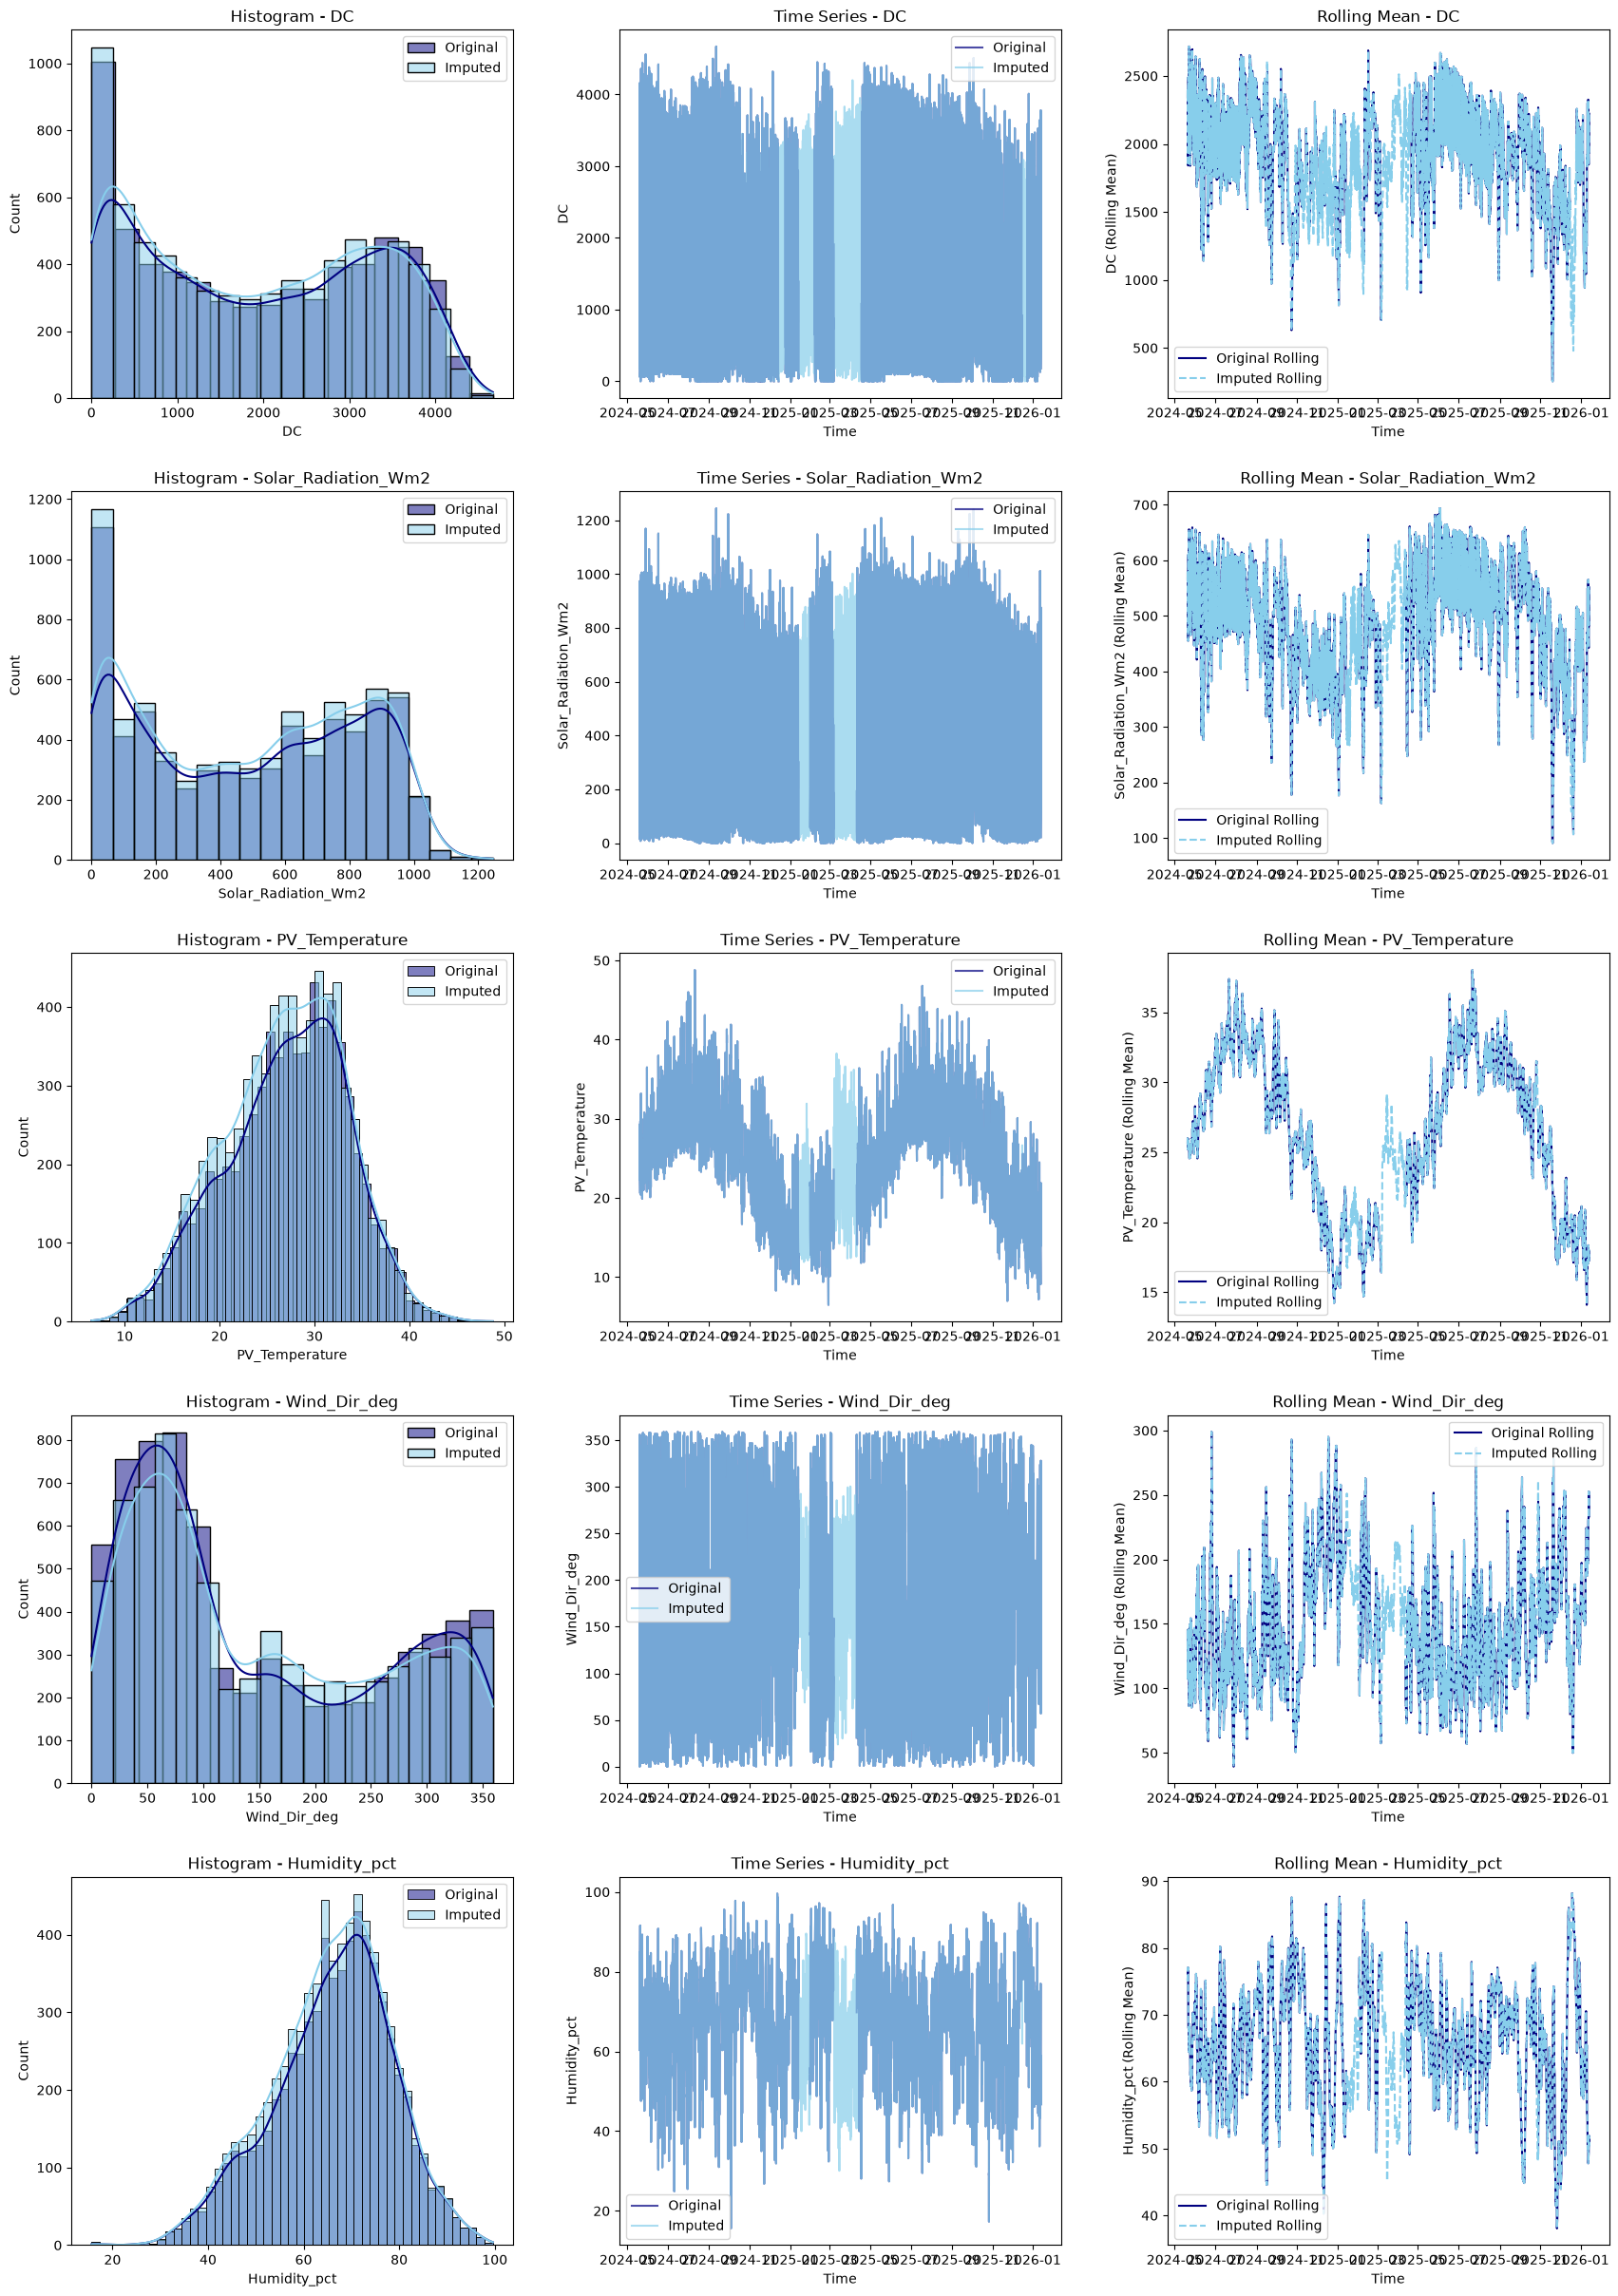

In [16]:
sns.set_palette("Blues")

imputed_columns = ['DC', 'Solar_Radiation_Wm2',
                   'Ambient_Temperature', 'PV_Temperature', 'Rain (mm)',
                   'Wind_Dir_deg', 'Wind_Speed', 'Humidity_pct',
                   'Dew_Point_C']

valid_cols = [col for col in imputed_columns if col in df_filtered.columns]

n_cols = 3
n_rows = len(valid_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.tight_layout(pad=5)

for i, col in enumerate(valid_cols):
    ax = axes[i, 0]
    sns.histplot(df_filtered[col].dropna(), color='navy', label='Original', kde=True, ax=ax)
    sns.histplot(df_imputed[col], color='skyblue', label='Imputed', kde=True, ax=ax, alpha=0.5)
    ax.set_title(f"Histogram - {col}")
    ax.legend()

    ax = axes[i, 1]
    ax.plot(df_filtered.index, df_filtered[col], label='Original', color='navy', alpha=0.7)
    ax.plot(df_filtered.index, df_imputed[col], label='Imputed', color='skyblue', alpha=0.7)
    ax.set_title(f"Time Series - {col}")
    ax.set_xlabel("Time")
    ax.set_ylabel(col)
    ax.legend()

    roll_orig = df_filtered[col].rolling(window=24).mean()
    roll_imputed = df_imputed[col].rolling(window=24).mean()
    ax = axes[i, 2]
    ax.plot(df_filtered.index, roll_orig, label='Original Rolling', color='navy')
    ax.plot(df_filtered.index, roll_imputed, label='Imputed Rolling', color='skyblue', linestyle='dashed')
    ax.set_title(f"Rolling Mean - {col}")
    ax.set_xlabel("Time")
    ax.set_ylabel(f"{col} (Rolling Mean)")
    ax.legend()

plt.show()

## Save imputed data

In [17]:
df_imputed.reset_index(inplace=True)
df_imputed.to_csv("../data/imputed_data.csv", index=False)
print(f"Saved imputed data. Shape: {df_imputed.shape}")

Saved imputed data. Shape: (7360, 13)
